# BCB Non-clone Small Graph Inspection

Counts graph layers with very small node counts and renders a few suspicious methods. Use this right after `../run_pipeline/02_extract_graphs.py` to catch empty CFG/DDG/PDG layers before running spectral extraction.

In [11]:
from pathlib import Path
import html
import json
import pickle
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import bcb_type_dir, output_root_for

VARIANT = "non_clone"
DATA_DIR = bcb_type_dir(VARIANT)
OUTPUT_ROOT = output_root_for("bcb", VARIANT)
GRAPH_MANIFEST_PATH = OUTPUT_ROOT / "clean_graphs" / "graph_shards_manifest.json"
SPECTRAL_MANIFEST_PATH = OUTPUT_ROOT / "spectral_features" / "spectral_features_manifest.json"
PIPELINE_TIMINGS_PATH = OUTPUT_ROOT / "pipeline_timings.json"
TIMING_STATS_PATH = OUTPUT_ROOT / "timing_stats.json"
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]
BASE_GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg"]

print("Project root:", PROJECT_ROOT)
print("Prepared non-clone data:", DATA_DIR)
print("Output root:", OUTPUT_ROOT)
print("Graph manifest:", GRAPH_MANIFEST_PATH if GRAPH_MANIFEST_PATH.exists() else "not found yet")
print("Spectral manifest:", SPECTRAL_MANIFEST_PATH if SPECTRAL_MANIFEST_PATH.exists() else "not found yet")

SMALL_NODE_LIMIT = 6
MAX_EXAMPLES = 10

if not GRAPH_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Graph manifest not found: {GRAPH_MANIFEST_PATH}. Run ../run_pipeline/02_extract_graphs.py first.")

manifest = json.loads(GRAPH_MANIFEST_PATH.read_text(encoding="utf-8"))
print("Graph methods:", manifest.get("total_methods"))
print("Graph shards:", len(manifest.get("shards", [])))


Project root: c:\Users\koush\PyProjects\spectrals\Spectral-Software
Prepared non-clone data: C:\Users\koush\PyProjects\spectrals\data\bcb\non_clone
Output root: C:\Users\koush\PyProjects\spectrals\outputs\bcb\non_clone
Graph manifest: C:\Users\koush\PyProjects\spectrals\outputs\bcb\non_clone\clean_graphs\graph_shards_manifest.json
Spectral manifest: C:\Users\koush\PyProjects\spectrals\outputs\bcb\non_clone\spectral_features\spectral_features_manifest.json
Graph methods: 55678
Graph shards: 56


In [12]:
small_rows = []
coverage_rows = []
method_small_counts: dict[str, int] = {}
all_method_ids: set[str] = set()

for shard_path in tqdm(manifest.get("shards", []), desc="Scanning graph shards", unit="shard"):
    with Path(shard_path).open("rb") as f:
        shard = pickle.load(f)
    for method_id, layers in shard.items():
        method_id = str(method_id)
        all_method_ids.add(method_id)
        for graph_type in GRAPH_TYPES:
            graph = layers.get(graph_type)
            nodes = 0 if graph is None else graph.number_of_nodes()
            edges = 0 if graph is None else graph.number_of_edges()
            coverage_rows.append({
                "method_id": method_id,
                "graph_type": graph_type,
                "present": graph is not None,
                "nodes": int(nodes),
                "edges": int(edges),
            })
            if nodes <= SMALL_NODE_LIMIT:
                small_rows.append({
                    "method_id": method_id,
                    "graph_type": graph_type,
                    "nodes": int(nodes),
                    "edges": int(edges),
                })
                method_small_counts[method_id] = method_small_counts.get(method_id, 0) + 1

coverage_df = pd.DataFrame(coverage_rows)
small_df = pd.DataFrame(small_rows)

summary_df = (
    coverage_df.groupby("graph_type")
    .agg(
        methods=("method_id", "nunique"),
        present_layers=("present", "sum"),
        empty_or_tiny=("nodes", lambda s: int((s <= SMALL_NODE_LIMIT).sum())),
        min_nodes=("nodes", "min"),
        p01_nodes=("nodes", lambda s: float(s.quantile(0.01))),
        median_nodes=("nodes", "median"),
        p99_nodes=("nodes", lambda s: float(s.quantile(0.99))),
        max_nodes=("nodes", "max"),
        median_edges=("edges", "median"),
    )
    .reset_index()
)
summary_df["tiny_fraction"] = summary_df["empty_or_tiny"] / summary_df["methods"].clip(lower=1)

display(summary_df)
display(small_df.head(50))

if small_df.empty:
    example_method_ids = []
else:
    ranked = sorted(method_small_counts.items(), key=lambda item: item[1], reverse=True)
    example_method_ids = [method_id for method_id, _ in ranked[:MAX_EXAMPLES]]
print("Example suspicious method ids:", example_method_ids)


Scanning graph shards: 100%|██████████| 56/56 [04:28<00:00,  4.80s/shard]


,graph_type,methods,present_layers,empty_or_tiny,min_nodes,p01_nodes,median_nodes,p99_nodes,max_nodes,median_edges,tiny_fraction
0,ast,55678,55677,6,0,8.0,78.0,957.23,7420,77.0,0.000108
1,cfg,55678,55677,5753,0,3.0,30.0,388.00,2870,31.0,0.103326
2,cpg,55678,55677,6,0,8.0,78.0,957.23,7420,171.0,0.000108
3,ddg,55678,55673,3995,0,5.0,30.0,320.23,1689,75.0,0.071752
4,pdg,55678,55677,3986,0,5.0,31.0,389.00,2811,88.0,0.071590


,method_id,graph_type,nodes,edges
0,10012630,cfg,4,3
1,10012630,ddg,6,9
2,10012630,pdg,6,9
3,10020006,cfg,6,6
4,10020518,cfg,3,2
5,10020518,ddg,5,6
6,10020518,pdg,5,6
7,10020987,cfg,3,2
8,10020987,ddg,5,6
9,10020987,pdg,5,6


Example suspicious method ids: ['12337362', '1264776', '16002243', '16002257', '22699548', '9514765', '10012630', '10020518', '10020987', '10023497']


## Source Line Counts vs. Tiny Graph Layers

This section checks whether tiny graph layers are mostly explained by tiny source methods. It loads the current non-clone `data.jsonl`, plots the method line-count distribution, reports descriptive statistics, and joins source size with the graph-layer scan above.


Loading source line counts: 55693method [00:00, 55802.57method/s]


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
raw_lines,55693,27.765985,46.018246,2.0,3.0,3.0,4.0,9.0,17.0,32.0,55.0,83.0,181.00,1626.0
nonempty_lines,55693,27.033361,44.940846,2.0,3.0,3.0,4.0,9.0,17.0,31.0,54.0,80.0,175.08,1626.0
chars,55693,1231.239581,2479.283527,37.0,53.0,84.0,153.0,323.0,668.0,1323.0,2496.0,3851.4,9497.68,93609.0
longest_line,55693,118.849137,368.305054,19.0,29.0,42.0,54.0,73.0,96.0,129.0,177.0,221.0,419.08,32644.0


,methods
nonempty_line_bucket,
<=3,5354
4-5,3324
6-10,8831
11-20,15199
21-50,16832
51-100,4332
101-250,1528
251-500,224
501-1000,56


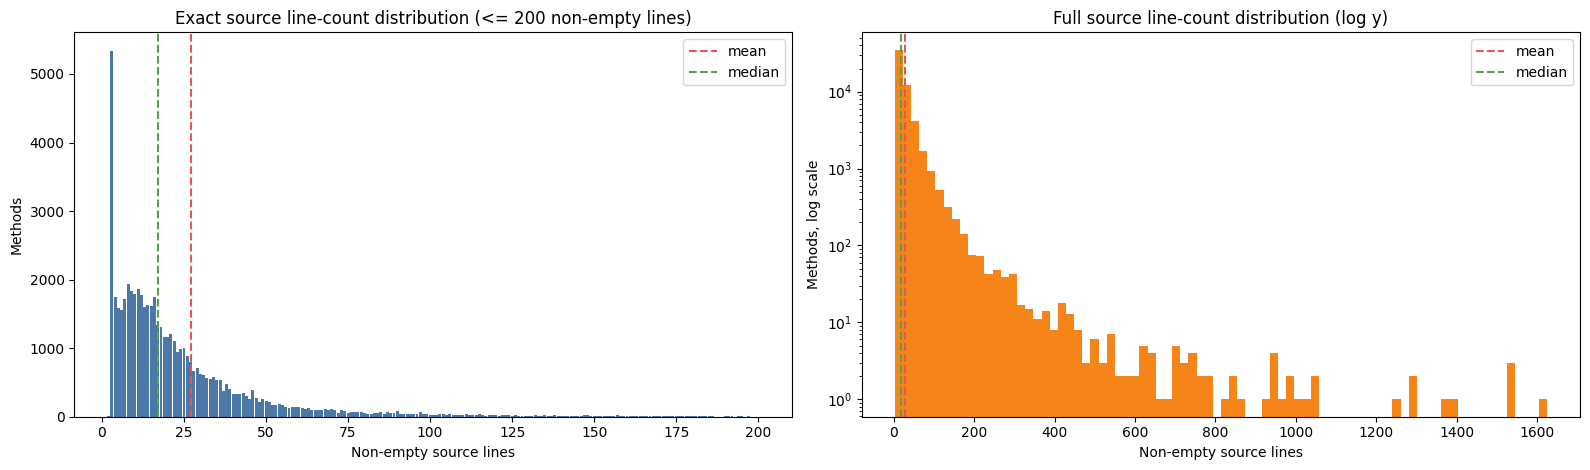

In [13]:
def load_code_size_dataframe(data_path: Path) -> pd.DataFrame:
    rows = []
    with data_path.open("r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Loading source line counts", unit="method"):
            if not line.strip():
                continue
            row = json.loads(line)
            method_id = str(row["idx"])
            code = row.get("func", "")
            raw_lines = code.splitlines() or [""]
            nonempty_lines = [source_line for source_line in raw_lines if source_line.strip()]
            rows.append({
                "method_id": method_id,
                "raw_lines": len(raw_lines),
                "nonempty_lines": len(nonempty_lines),
                "chars": len(code),
                "longest_line": max((len(source_line) for source_line in raw_lines), default=0),
            })
    return pd.DataFrame(rows)


code_size_df = load_code_size_dataframe(DATA_DIR / "data.jsonl")
LINE_BUCKETS = [-1, 3, 5, 10, 20, 50, 100, 250, 500, 1000, np.inf]
LINE_BUCKET_LABELS = ["<=3", "4-5", "6-10", "11-20", "21-50", "51-100", "101-250", "251-500", "501-1000", ">1000"]
code_size_df["line_bucket"] = pd.cut(
    code_size_df["nonempty_lines"],
    bins=LINE_BUCKETS,
    labels=LINE_BUCKET_LABELS,
)

line_stats = code_size_df[["raw_lines", "nonempty_lines", "chars", "longest_line"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T
line_stats["count"] = line_stats["count"].astype(int)
display(line_stats)

display(
    code_size_df["line_bucket"]
    .value_counts(sort=False)
    .rename_axis("nonempty_line_bucket")
    .to_frame("methods")
)

line_counts = code_size_df["nonempty_lines"].value_counts().sort_index()
max_exact_line = min(200, int(code_size_df["nonempty_lines"].max()))
exact_counts = line_counts[line_counts.index <= max_exact_line]

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
axes[0].bar(exact_counts.index, exact_counts.values, width=0.9, color="#4C78A8")
axes[0].axvline(code_size_df["nonempty_lines"].mean(), color="#E45756", linestyle="--", linewidth=1.5, label="mean")
axes[0].axvline(code_size_df["nonempty_lines"].median(), color="#54A24B", linestyle="--", linewidth=1.5, label="median")
axes[0].set_title(f"Exact source line-count distribution (<= {max_exact_line} non-empty lines)")
axes[0].set_xlabel("Non-empty source lines")
axes[0].set_ylabel("Methods")
axes[0].legend()

axes[1].hist(code_size_df["nonempty_lines"], bins=80, color="#F58518", log=True)
axes[1].axvline(code_size_df["nonempty_lines"].mean(), color="#E45756", linestyle="--", linewidth=1.5, label="mean")
axes[1].axvline(code_size_df["nonempty_lines"].median(), color="#54A24B", linestyle="--", linewidth=1.5, label="median")
axes[1].set_title("Full source line-count distribution (log y)")
axes[1].set_xlabel("Non-empty source lines")
axes[1].set_ylabel("Methods, log scale")
axes[1].legend()
plt.tight_layout()
plt.show()


,graph_type,methods,tiny_graphs,tiny_fraction,tiny_code_line_mean,tiny_code_line_median,tiny_code_line_p90,tiny_code_line_max,tiny_with_code_<=3_lines,tiny_with_code_<=3_fraction,tiny_with_code_<=5_lines,tiny_with_code_<=5_fraction,tiny_with_code_<=10_lines,tiny_with_code_<=10_fraction,tiny_with_code_<=20_lines,tiny_with_code_<=20_fraction,tiny_with_code_<=50_lines,tiny_with_code_<=50_fraction,tiny_with_code_<=100_lines,tiny_with_code_<=100_fraction
0,ast,55678,6,0.000108,10.000000,4.5,23.5,34,3,0.500000,3,0.500000,4,0.666667,5,0.833333,6,1.000000,6,1.000000
1,cfg,55678,5753,0.103326,3.372154,3.0,4.0,34,4560,0.792630,5533,0.961759,5746,0.998783,5750,0.999479,5753,1.000000,5753,1.000000
2,cpg,55678,6,0.000108,10.000000,4.5,23.5,34,3,0.500000,3,0.500000,4,0.666667,5,0.833333,6,1.000000,6,1.000000
3,ddg,55678,3995,0.071752,3.936421,3.0,3.0,960,3614,0.904631,3955,0.989987,3989,0.998498,3990,0.998748,3991,0.998999,3991,0.998999
4,pdg,55678,3986,0.071590,3.134220,3.0,3.0,34,3613,0.906422,3951,0.991219,3984,0.999498,3985,0.999749,3986,1.000000,3986,1.000000


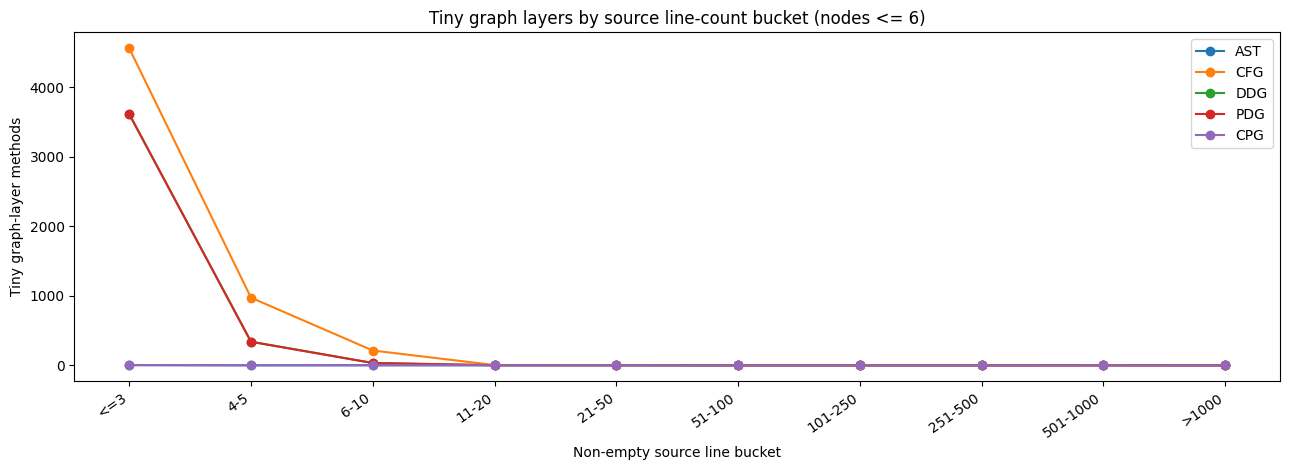

graph_type,ast,cfg,cpg,ddg,pdg
line_bucket,,,,,
<=3,0.06%,85.17%,0.06%,67.50%,67.48%
4-5,0.00%,29.27%,0.00%,10.26%,10.17%
6-10,0.01%,2.41%,0.01%,0.39%,0.37%
11-20,0.01%,0.03%,0.01%,0.01%,0.01%
21-50,0.01%,0.02%,0.01%,0.01%,0.01%
51-100,0.00%,0.00%,0.00%,0.00%,0.00%
101-250,0.00%,0.00%,0.00%,0.00%,0.00%
251-500,0.00%,0.00%,0.00%,0.00%,0.00%
501-1000,0.00%,0.00%,0.00%,7.41%,0.00%


CFG tiny methods: 5,753
CFG tiny with code <=   3 non-empty lines:  4,560 (79.26%)
CFG tiny with code <=   5 non-empty lines:  5,533 (96.18%)
CFG tiny with code <=  10 non-empty lines:  5,746 (99.88%)
CFG tiny with code <=  20 non-empty lines:  5,750 (99.95%)
CFG tiny with code <=  50 non-empty lines:  5,753 (100.00%)
CFG tiny with code <= 100 non-empty lines:  5,753 (100.00%)


,cfg_tiny_methods
nonempty_line_bucket,
<=3,4560
4-5,973
6-10,213
11-20,4
21-50,3
51-100,0
101-250,0
251-500,0
501-1000,0


,method_id,nonempty_lines,raw_lines,chars,nodes,edges,line_bucket
77886,16002243,34,34,2600,2,1,21-50
30176,12369343,33,36,1412,6,5,21-50
158566,22378916,25,28,966,6,5,21-50
77891,16002257,13,13,1063,0,0,11-20
222136,5781159,12,12,226,6,7,11-20
146131,21366910,11,11,274,6,6,11-20
219376,557372,11,11,293,6,8,11-20
218131,5481422,10,10,207,5,6,6-10
30121,12363968,10,10,240,6,6,6-10
52876,14111120,10,11,229,6,6,6-10


In [14]:
graph_code_df = coverage_df.merge(code_size_df, on="method_id", how="left")
graph_code_df["tiny_graph"] = graph_code_df["nodes"] <= SMALL_NODE_LIMIT

code_small_thresholds = [3, 5, 10, 20, 50, 100]
tiny_summary_rows = []
for graph_type, graph_group in graph_code_df.groupby("graph_type"):
    tiny_group = graph_group[graph_group["tiny_graph"]].copy()
    row = {
        "graph_type": graph_type,
        "methods": int(graph_group["method_id"].nunique()),
        "tiny_graphs": int(len(tiny_group)),
        "tiny_fraction": float(len(tiny_group) / max(len(graph_group), 1)),
        "tiny_code_line_mean": float(tiny_group["nonempty_lines"].mean()) if not tiny_group.empty else np.nan,
        "tiny_code_line_median": float(tiny_group["nonempty_lines"].median()) if not tiny_group.empty else np.nan,
        "tiny_code_line_p90": float(tiny_group["nonempty_lines"].quantile(0.90)) if not tiny_group.empty else np.nan,
        "tiny_code_line_max": int(tiny_group["nonempty_lines"].max()) if not tiny_group.empty else 0,
    }
    for threshold in code_small_thresholds:
        row[f"tiny_with_code_<={threshold}_lines"] = int((tiny_group["nonempty_lines"] <= threshold).sum())
        row[f"tiny_with_code_<={threshold}_fraction"] = float((tiny_group["nonempty_lines"] <= threshold).mean()) if not tiny_group.empty else np.nan
    tiny_summary_rows.append(row)

tiny_source_summary_df = pd.DataFrame(tiny_summary_rows).sort_values("graph_type")
display(tiny_source_summary_df)

bucket_tiny_counts = (
    graph_code_df[graph_code_df["tiny_graph"]]
    .groupby(["graph_type", "line_bucket"], observed=False)
    .size()
    .reset_index(name="tiny_graph_methods")
)

plt.figure(figsize=(13, 4.8))
for graph_type in GRAPH_TYPES:
    plot_df = bucket_tiny_counts[bucket_tiny_counts["graph_type"] == graph_type]
    plt.plot(plot_df["line_bucket"].astype(str), plot_df["tiny_graph_methods"], marker="o", label=graph_type.upper())
plt.title(f"Tiny graph layers by source line-count bucket (nodes <= {SMALL_NODE_LIMIT})")
plt.xlabel("Non-empty source line bucket")
plt.ylabel("Tiny graph-layer methods")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

bucket_tiny_rate = (
    graph_code_df
    .groupby(["graph_type", "line_bucket"], observed=False)
    .agg(
        methods=("method_id", "count"),
        tiny_graphs=("tiny_graph", "sum"),
        median_nodes=("nodes", "median"),
    )
    .reset_index()
)
bucket_tiny_rate["tiny_fraction"] = bucket_tiny_rate["tiny_graphs"] / bucket_tiny_rate["methods"].clip(lower=1)

display(
    bucket_tiny_rate.pivot(index="line_bucket", columns="graph_type", values="tiny_fraction")
    .loc[LINE_BUCKET_LABELS]
    .style.format("{:.2%}")
)

cfg_tiny_df = graph_code_df[(graph_code_df["graph_type"] == "cfg") & (graph_code_df["tiny_graph"])].copy()
print(f"CFG tiny methods: {len(cfg_tiny_df):,}")
for threshold in code_small_thresholds:
    count = int((cfg_tiny_df["nonempty_lines"] <= threshold).sum())
    fraction = count / max(len(cfg_tiny_df), 1)
    print(f"CFG tiny with code <= {threshold:>3} non-empty lines: {count:>6,} ({fraction:.2%})")

cfg_tiny_by_bucket = (
    cfg_tiny_df["line_bucket"]
    .value_counts(sort=False)
    .rename_axis("nonempty_line_bucket")
    .to_frame("cfg_tiny_methods")
)
display(cfg_tiny_by_bucket)

display(
    cfg_tiny_df
    .sort_values(["nonempty_lines", "nodes", "edges"], ascending=[False, True, True])
    [["method_id", "nonempty_lines", "raw_lines", "chars", "nodes", "edges", "line_bucket"]]
    .head(30)
)


In [15]:
def load_code_for_ids(path: Path, wanted_ids: set[str]) -> dict[str, str]:
    code_map = {}
    if not wanted_ids:
        return code_map
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            method_id = str(row["idx"])
            if method_id in wanted_ids:
                code_map[method_id] = row.get("func", "")
                if len(code_map) == len(wanted_ids):
                    break
    return code_map


def load_graphs_for_ids(manifest: dict, wanted_ids: set[str]) -> dict[str, dict]:
    graphs = {}
    if not wanted_ids:
        return graphs
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(graphs)):
            if method_id in shard:
                graphs[method_id] = shard[method_id]
        if len(graphs) == len(wanted_ids):
            break
    return graphs


code_map = load_code_for_ids(DATA_DIR / "data.jsonl", set(example_method_ids))
graph_map = load_graphs_for_ids(manifest, set(example_method_ids))
print("Loaded examples:", len(code_map), len(graph_map))


Loaded examples: 10 10


,method_id,graph_type,nodes,edges
1490,12337362,ast,6,5
1491,12337362,cfg,2,1
1494,12337362,cpg,6,6
1492,12337362,ddg,3,2
1493,12337362,pdg,3,2


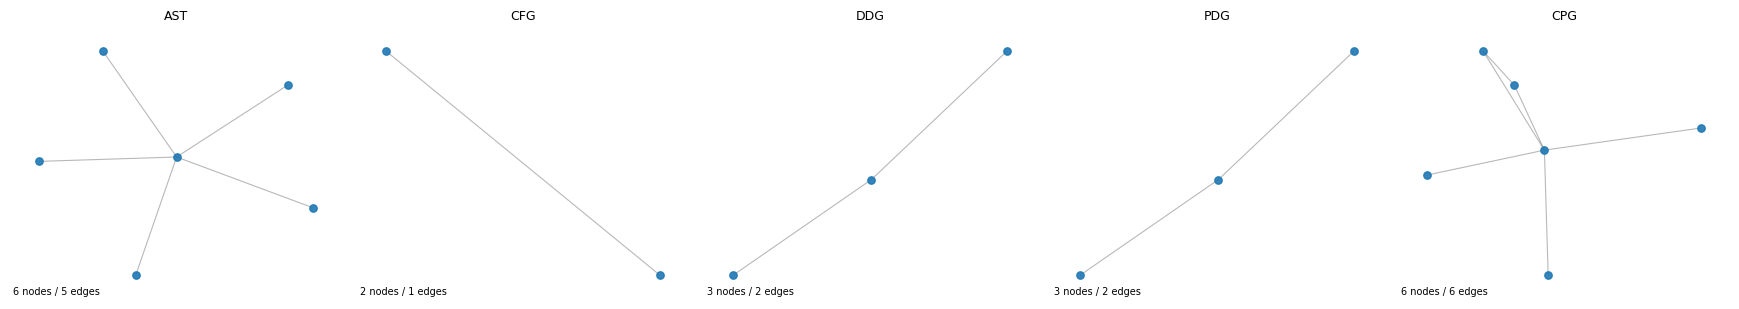

,method_id,graph_type,nodes,edges
1668,1264776,ast,6,5
1669,1264776,cfg,2,1
1672,1264776,cpg,6,6
1670,1264776,ddg,3,2
1671,1264776,pdg,3,2


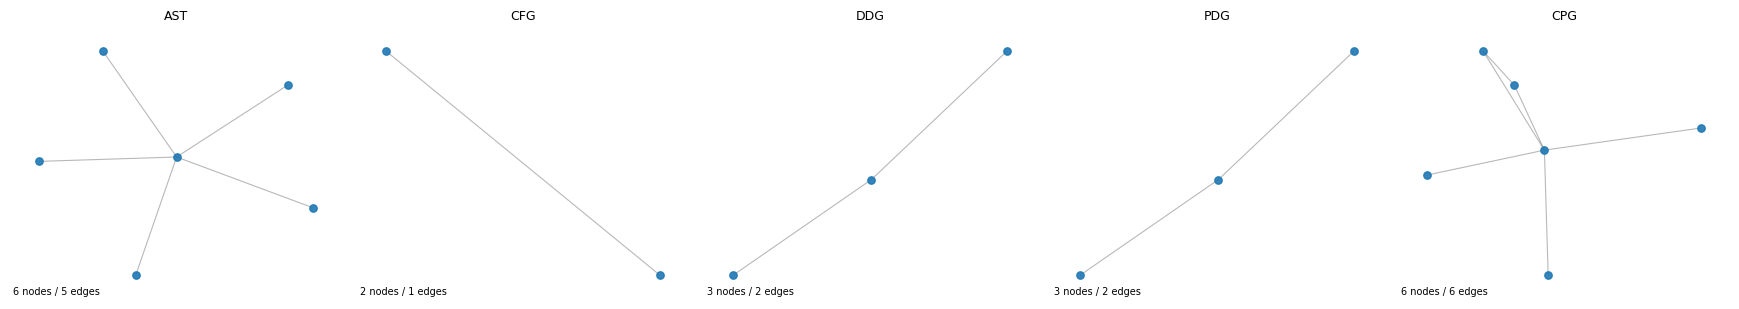

,method_id,graph_type,nodes,edges
4093,16002243,ast,6,5
4094,16002243,cfg,2,1
4097,16002243,cpg,6,6
4095,16002243,ddg,3,2
4096,16002243,pdg,3,2


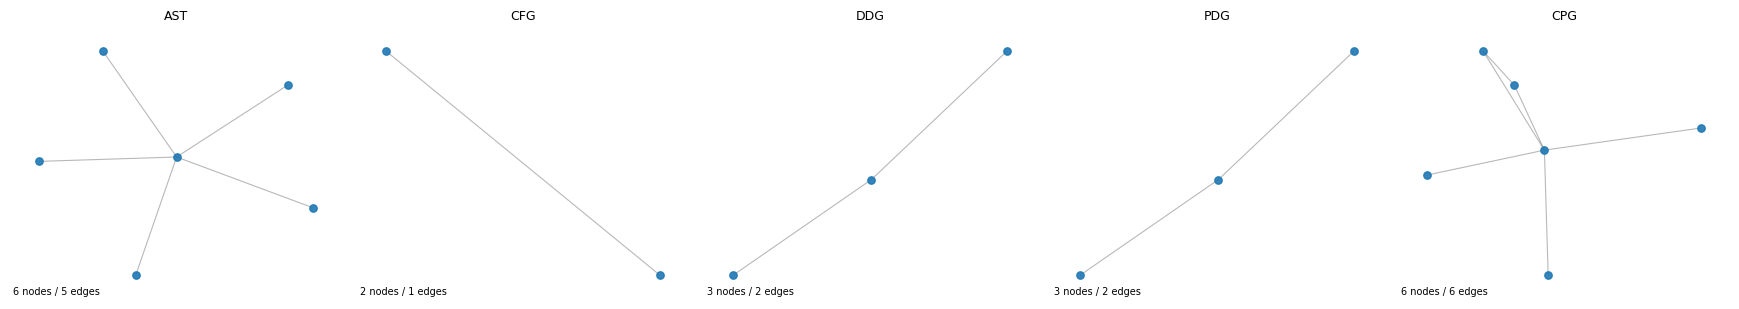

,method_id,graph_type,nodes,edges
4098,16002257,ast,0,0
4099,16002257,cfg,0,0
4102,16002257,cpg,0,0
4100,16002257,ddg,0,0
4101,16002257,pdg,0,0


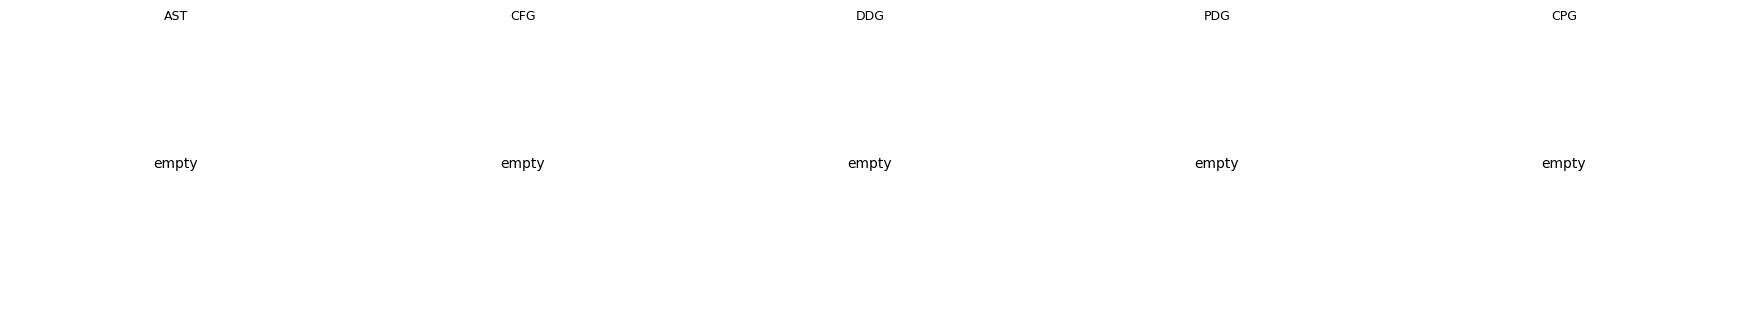

,method_id,graph_type,nodes,edges
8440,22699548,ast,6,5
8441,22699548,cfg,2,1
8444,22699548,cpg,6,6
8442,22699548,ddg,3,2
8443,22699548,pdg,3,2


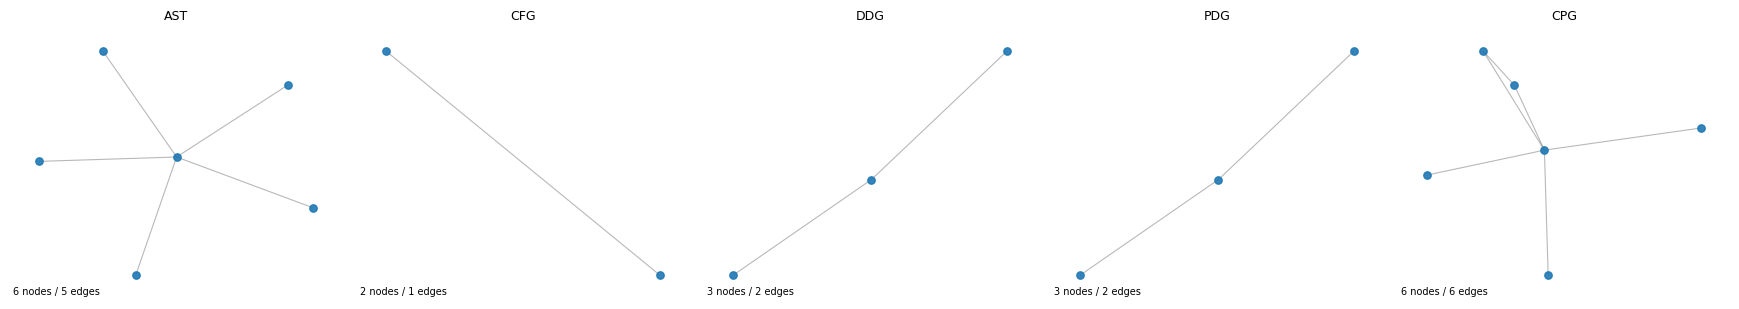

,method_id,graph_type,nodes,edges
13433,9514765,ast,6,5
13434,9514765,cfg,3,2
13437,9514765,cpg,6,9
13435,9514765,ddg,4,4
13436,9514765,pdg,4,4


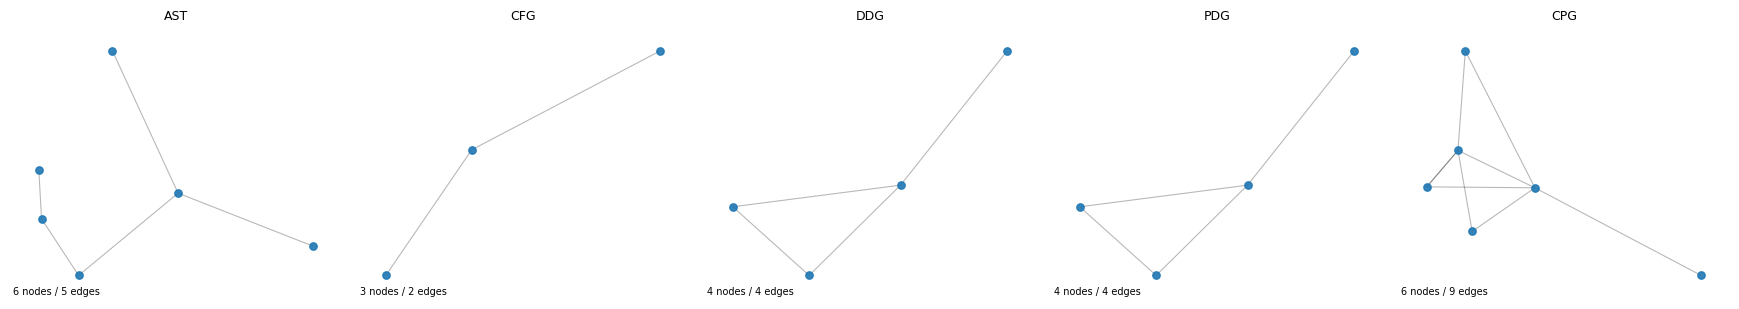

,method_id,graph_type,nodes,edges
0,10012630,cfg,4,3
1,10012630,ddg,6,9
2,10012630,pdg,6,9


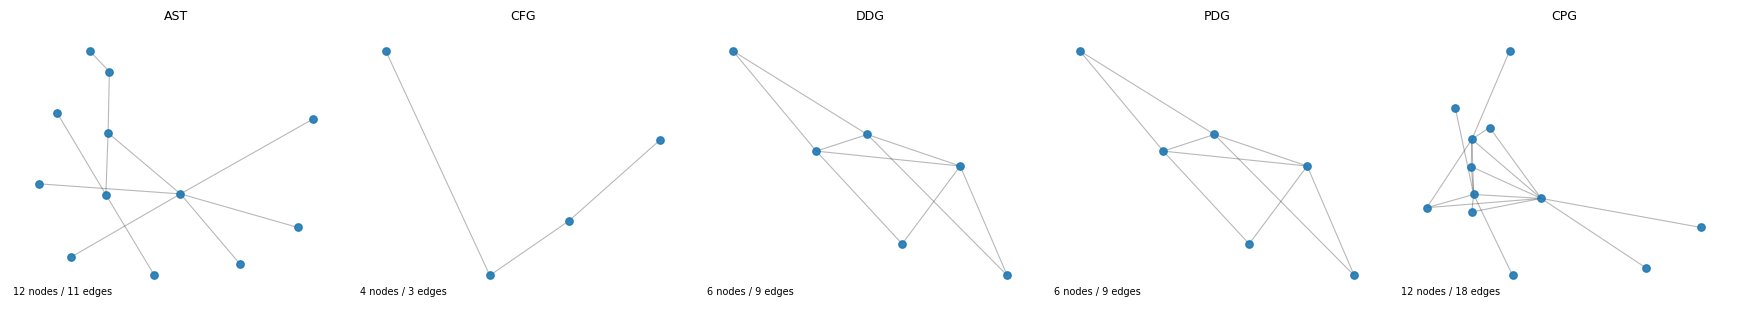

,method_id,graph_type,nodes,edges
4,10020518,cfg,3,2
5,10020518,ddg,5,6
6,10020518,pdg,5,6


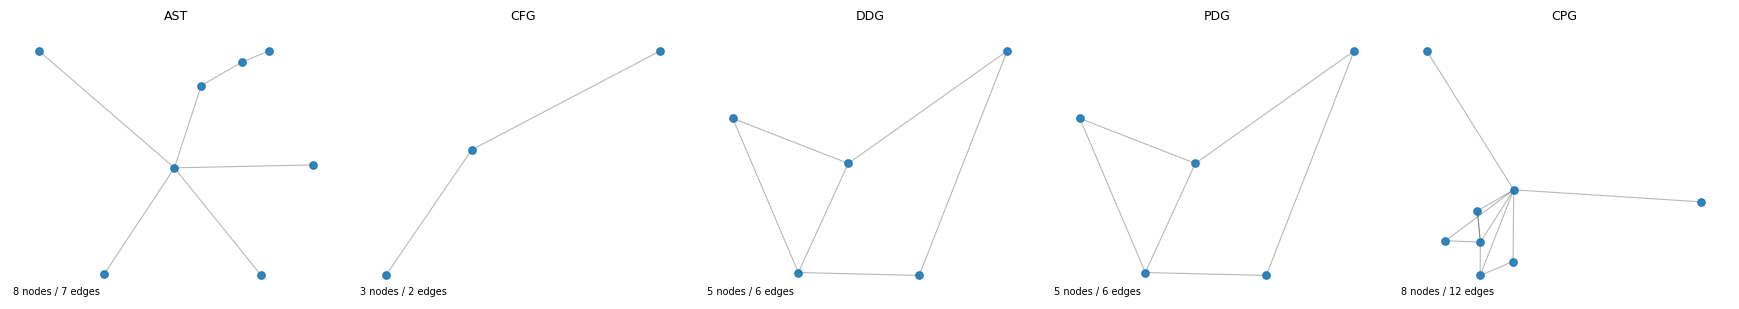

,method_id,graph_type,nodes,edges
7,10020987,cfg,3,2
8,10020987,ddg,5,6
9,10020987,pdg,5,6


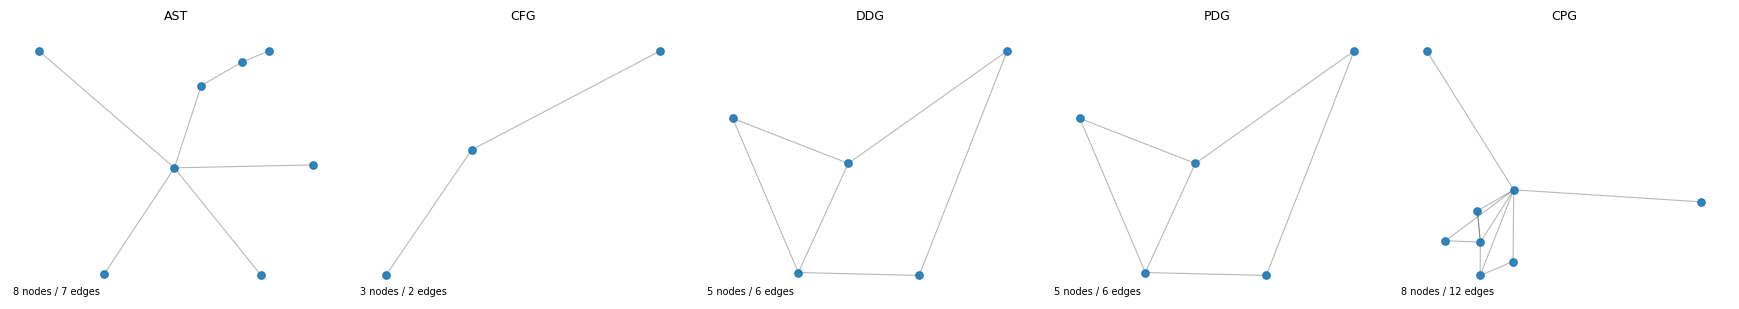

,method_id,graph_type,nodes,edges
10,10023497,cfg,3,2
11,10023497,ddg,5,6
12,10023497,pdg,5,6


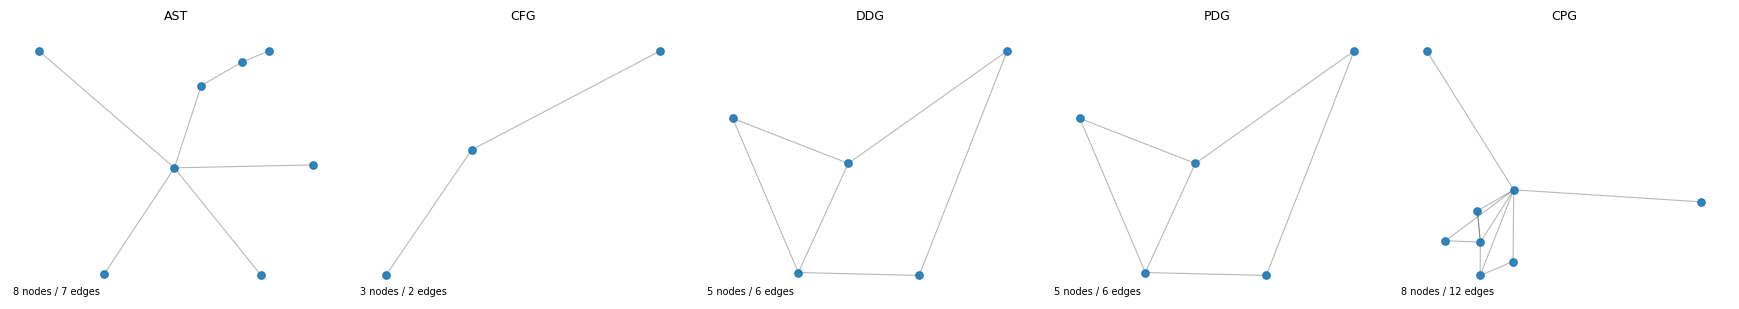

In [16]:
def draw_graph(graph: nx.DiGraph | None, title: str, ax) -> None:
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty", ha="center", va="center")
        return
    graph = nx.DiGraph(graph)
    shown = graph if graph.number_of_nodes() <= 120 else graph.subgraph(list(graph.nodes())[:120]).copy()
    pos = nx.spring_layout(shown, seed=42)
    nx.draw_networkx_edges(shown, pos, ax=ax, arrows=False, alpha=0.28, width=0.8)
    nx.draw_networkx_nodes(shown, pos, ax=ax, node_size=28, alpha=0.9)
    ax.text(0.01, 0.02, f"{graph.number_of_nodes()} nodes / {graph.number_of_edges()} edges", transform=ax.transAxes, fontsize=7)


def show_method(method_id: str) -> None:
    code_html = html.escape(code_map.get(method_id, ""))
    small_layers = small_df[small_df["method_id"] == method_id].sort_values("graph_type")
    display(HTML(f'''
    <h3>method {html.escape(method_id)}</h3>
    <pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;max-height:420px;overflow:auto;">{code_html}</pre>
    '''))
    display(small_layers)

    fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(3.5 * len(GRAPH_TYPES), 3.2))
    for ax, graph_type in zip(axes, GRAPH_TYPES):
        draw_graph(graph_map.get(method_id, {}).get(graph_type), graph_type.upper(), ax)
    plt.tight_layout()
    plt.show()


for method_id in example_method_ids:
    show_method(method_id)
